# Manipulación de datos (Data Wrangling) (continuación)
## Convertir a un tipo de datos específico con astype()

El método astype() de pandas te permite convertir tipos de datos.

Al igual que con otros métodos de pandas, existe para DataFrames y Series.

Al usarlo, debes especificar entre paréntesis el tipo de datos al cual deseas convertirlo. Por ejemplo, df['column'] = df['column'].astype('int') convertiría la columna 'column' al tipo de datos entero.

In [1]:
import pandas as pd

data = {
    'StockCode': ['10001', '10002', '10003', '10004', '10005', '10006'],
    'Description': ['Mug', 'T-shirt', 'Notebook', 'Invalid Code', 'Float code', 'Pen'],
    'Quantity': [10, 5, 8, 1, 3, 6],
    'UnitPrice': [2.5, 15.0, 4.2, 1.0, 6.75, 1.5]
}

df = pd.DataFrame(data)

# df.info()
#1. Convierte 'StockCode' a tipo de dato entero 'int'
df['StockCode'] = df['StockCode'].astype('int')

#2. Valida el cambio ejecutando el metodo info() sobre el dataframe
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   StockCode    6 non-null      int64  
 1   Description  6 non-null      object 
 2   Quantity     6 non-null      int64  
 3   UnitPrice    6 non-null      float64
dtypes: float64(1), int64(2), object(1)
memory usage: 324.0+ bytes


astype() pueda fallar si tratamos de convertir un stringo "1.0" a int, por lo que tenemos un método mas flexible to_numeric()

In [2]:
import pandas as pd

df = pd.read_csv('./datasets/OnlineRetail.csv', encoding='ISO-8859-1')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%Y-%m-%dT%H:%M:%SZ')

df['InvoiceDate'] = df['InvoiceDate'].dt.tz_localize('UTC')

print(df['InvoiceDate'].head())

ValueError: time data "12/1/2010 8:26" doesn't match format "%Y-%m-%dT%H:%M:%SZ", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

### Parámetro errors=
Si hay caracteres alfabéticos, to_numeric por si mismo, fallará, por eso ocupamos el ``parametro errors=``.

Para eso, vamos a añadir el parametro ``errors='coerce'`` el cual remplazará el valor no valido  por NaN. 

In [ ]:
import pandas as pd

d = {'col1': ['1.0', 'B.0'], 'col2': ['3', '4']}
df = pd.DataFrame(data=d)

df['col2'] = df['col2'].astype('int')
df['col1'] = pd.to_numeric(df['col1'], errors='coerce')

print(df.dtypes)
print(df)

## ¿Qué hace np.array_equal()?
Imagina que tienes dos listas de números y quieres saber si son exactamente iguales, posición por posición. Eso es justo lo que hace np.array_equal(array1, array2).

### Sintaxis

``np.array_equal(array1, array2)``

Esta funcion hace parte de ``NumPy``, una librería de Python que hace que trabajar con números sea mucho más fácil y rápido. Pandas usa NumPy “por debajo del capó” para manejar datos, especialmente cuando queremos hacer operaciones matemáticas con muchos valores a la vez.

### ¿Qué es un array?
Un array (o arreglo) en NumPy es como una lista de Python

### ¿Qué resultado arroja?
Devuelve True si todos los elementos de ambos arrays son iguales y en el mismo orden. Si hay al menos un número diferente, devuelve False.

Para ilustrar esto, mira el siguiente ejemplo donde revisamos si al convertir los valores de la primera columna a enteros resultan los mismos valores:

In [ ]:
import numpy as np
import pandas as pd

d = {'col1': [1.0, 2.0, 3.0, 4.0], 'col2': [5.0, 6.01, 7.0, 8.0]}
df = pd.DataFrame(data=d)

# comprueba si es seguro convertir 'col1' con np.array_equal
print(np.array_equal(df['col1'], df['col1'].astype('int'))) # => true Aquí estaríamos checando si todos los valores de col1 son tipo int

# comprueba si es seguro convertir 'col2' con np.array_equal
print(np.array_equal(df['col2'], df['col2'].astype('int'))) # => false Aquí estaríamos checando si todos los valores de col2 son tipo int

## Trabajar con fechas y horas
Las fechas no se escriben igual en todos los países.
Por ejemplo, en muchos lugares se prefiere el formato día/mes/año, así que el 8 de marzo de 2010 se escribe como 08/03/2010.
En cambio, en Estados Unidos es común el formato mes/día/año, por lo que 08/03/2010 significaría el 3 de agosto.
### ¿Cómo convertimos una fecha string a datetime?
Usamos el método to_datetime() de pandas. Este método transforma textos con formato de fecha (como '2010-12-17T12:38:00Z') en objetos datetime que pandas puede entender.

Veamos un ejemplo sencillo:

In [ ]:
string_date = '2010-12-17T12:38:00Z'
datetime_date = pd.to_datetime(string_date, format='%Y-%m-%dT%H:%M:%SZ')

print(type(string_date))      # <class 'str'>
print(type(datetime_date))    # <class 'Timestamp'>
print(datetime_date)          # 2010-12-17 12:38:00

Cuando usas to_datetime(), puedes pasarle un patrón con el parámetro format= para decirle cómo interpretar el texto.

En el ejemplo anterior:

format='%Y-%m-%dT%H:%M:%SZ'
Cada símbolo representa una parte de la fecha:

- %Y: año con 4 dígitos (2010)
- %m: mes (12)
- %d: día (17)
- %H: hora en 24 horas (12)
- %M: minutos (38)
- %S: segundos (00)

La letra T y la Z son parte del texto y deben coincidir exactamente

Consulta [aquí](https://docs.python.org/3/library/datetime.html#strftime-and-strptime-behavior) mas información al respecto.

### Ejercicio 2: Revisando los tipos de datos
El equipo de analítica necesita trabajar con los datos de tiempo, pero antes debemos verificar si pandas los reconoce como fechas o como strings. Usa el método .info() para revisar los tipos de datos del dataframe position

In [ ]:
import pandas as pd
data = {
    'timestamp':['2019-02-04T13:22:34','2019-02-06T15:30:54','2019-02-08T14:53:45','2019-02-10T16:50:22', '2019-02-12T14:16:28'],
    'level':[1,4,1,2,1],
    'page_id': ['6ukoNykP', 'Q62R1Ue7', 'GmfSxgPs', 'M56OK96C', 'q2fqVqPc']
}
position = pd.DataFrame(data)

position['timestamp'] = pd.to_datetime(position['timestamp'], format='%Y-%m-%dT%H:%M:%S')

print(position.head())
print("---------------------------------")
position.info()

## Trabajar con atributos datetime y zonas horarias

In [ ]:
import pandas as pd
data = {
    'timestamp':['2019-02-04T13:22:34','2019-02-06T15:30:54','2019-02-08T14:53:45','2019-02-10T16:50:22', '2019-02-12T14:16:28'],
    'level':[1,4,1,2,1],
    'page_id': ['6ukoNykP', 'Q62R1Ue7', 'GmfSxgPs', 'M56OK96C', 'q2fqVqPc']
}
position = pd.DataFrame(data)

position['timestamp'] = pd.to_datetime(position['timestamp'], format='%Y-%m-%dT%H:%M:%S')

position.info()
print("---------------------------------")
print(position['timestamp'][0])

### Extraer día, mes año de las fechas

¿Qué puedes extraer con .dt?
Pandas te permite acceder a muchos otros atributos de las fechas usando .dt, como:

.dt.year → año
.dt.month → mes
.dt.day → día
.dt.hour → hora
.dt.minute → minuto
.dt.weekday → día de la semana (0 = lunes, 6 = domingo)
.dt.date → solo la fecha, sin la hora
Puedes ver más opciones en la [documentación oficial](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#time-date-components).

In [ ]:
import pandas as pd
data = {
    'timestamp':['2019-02-04T13:22:34','2019-02-06T15:30:54','2019-02-08T14:53:45','2019-02-10T16:50:22', '2019-02-12T14:16:28'],
    'level':[1,4,1,2,1],
    'page_id': ['6ukoNykP', 'Q62R1Ue7', 'GmfSxgPs', 'M56OK96C', 'q2fqVqPc']
}
position = pd.DataFrame(data)

position['timestamp'] = pd.to_datetime(position['timestamp'], format='%Y-%m-%dT%H:%M:%S')

position.info()
print("---------------------------------")
position['Day'] = position['timestamp'].dt.day
position['Month'] = position['timestamp'].dt.month
position['Year'] = position['timestamp'].dt.year
print(position[['timestamp', 'Day', 'Month', 'Year']].head(5))

### Trabajar con husos horarios
Para convertir datos de un huso horario a otro, pandas ofrece dos herramientas poderosas:

.dt.tz_localize() — asigna una zona horaria a una columna de tipo datetime.
.dt.tz_convert() — convierte una columna con zona horaria a otra zona horaria diferente.
Es decir  .dt.tz_localize()  te permite asignar una zona horaria a una columna datetime para que tus datos "tengan conocimiento" de su zona horaria. .dt.tz_convert() te permite convertir una columna "con conocimiento de su zona horaria" en una zona horaria distinta.

#### Paso 1: Asignar una zona horaria
Supongamos que la columna 'InvoiceDate' de tu tienda online está en formato UTC. Vamos a especificarlo con .tz_localize():

In [ ]:
import pandas as pd

df = pd.read_csv('./datasets/OnlineRetail.csv', encoding='ISO-8859-1')
# 12/1/2010 8:26,2.55
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%Y %H:%M')

df['InvoiceDate'] = df['InvoiceDate'].dt.tz_localize('UTC') # en la parte inferior nos aparecerá que es datetime con UTC

print(df['InvoiceDate'].head())
print("----------------------------------------------------------")

df['InvoiceDate_NYC'] = df['InvoiceDate'].dt.tz_convert('America/New_York') # tz_convert solo funciona si ya se usó un localize
# previamente, si no se ha usado, debes de usar un .tz_localize('America/New_York')

print(df['InvoiceDate_NYC'].head())


## El método apply()
Para crear una columna de categoría de época usando nuestra función personalizada era_group(), necesitaremos llamar al método apply(), el cual toma valores de una columna DataFrame y les aplica una función.

En este caso, el método apply() se debe aplicar a la columna 'year_of_release' column, porque 'year_of_release' contiene los datos que la función usará como input. La función era_group() se convierte entonces en el argumento que pasamos al método apply().

In [ ]:
import pandas as pd

df = pd.read_csv('./datasets/OnlineRetail.csv', encoding='ISO-8859-1')
# 12/1/2010 8:26,2.55
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%Y %H:%M')

df['InvoiceDate'] = df['InvoiceDate'].dt.tz_localize('UTC')

df['year_of_release'] = df['InvoiceDate'].dt.year

def era_group(year):
    """
    La función devuelve el grupo de época de los juegos de acuerdo con el año de lanzamiento usando estas reglas:
    —'retro'   para año < 2000
    —'modern'  para 2000 <= año < 2010
    —'recent'  para año >= 2010
    —'unknown' para buscar valores año (NaN)
    """

    if year < 2000:
        return 'retro'
    elif year < 2010:
        return 'modern'
    elif year >= 2010:
        return 'recent'
    else:
        return 'unknown'
    
df['era_group'] = df['year_of_release'].apply(era_group) # apply(era_group => call to function: era_group())
# con apply({func}), estamos insertando una función en apply, que categoriza según el año, y lo almacenamos en una 
# nueva columna llamada era_group
# df.apply(post_code_and_address_to_territory_group, axis=0) pasa los valores de la columna
# df.apply(post_code_and_address_to_territory_group, axis=1) pasa los valores de la fila, es lo deseado

df_grouped = df.groupby('era_group')

print(df_grouped['UnitPrice'].mean())

## Groupby() nivel medio
El método agg()
Hasta ahora, solo hemos aplicado una única función a nuestros grupos. Pero, ¿qué pasa si queremos calcular diferentes estadísticas de resumen para diferentes columnas? Por ejemplo, tanto la puntuación promedio de los críticos como el total de ventas en Japón para cada grupo. Podemos conseguirlo utilizando el método agg(), que es la abreviatura de "aggregate" (agregar).

El método agg() usa un diccionario como entrada donde las claves son los nombres de columnas y los valores correspondientes son las funciones de agregación que quieres aplicarles:

In [ ]:
import pandas as pd

df = pd.read_csv('./datasets/vg_sales.csv')
df.dropna(inplace=True)

def dolarize_it(sales):
    sales = sales.mean() * 100 # multiplica la suma anterior por 100, ya que son 100 centavos por dolar
    return f"${sales:,.2f}M" # formatea la salida para evitar una cantidad larga de decimales

agg_dict = {'NA_Sales': dolarize_it, 'EU_Sales': 'mean', 'JP_Sales': 'mean'}
# Funciones como cadenas de texto (strings)
# "mean", "sum", "min", "max", "count", "median", "std", "var", o llamar una función personalizada como dolarize_it

grp = df.groupby(['Platform', 'Genre'])
print(grp.agg(agg_dict))

### Tablas dinamicas con pivot_table()
Las tablas dinámicas, nos van a generar un nuevo "DataFrame", donde convertiremos los registros únicos de una columna, en las columnas, para un análisis mas práctico.

Creamos una tabla dinámica utilizando el método pivot_table(), que tiene un nombre muy apropiado. Los parámetros que utilizamos fueron:

- index=: la columna cuyos valores se convierten en índices en la tabla dinámica;
- columns=: la columna cuyos valores se convierten en columnas en la tabla dinámica;
- values=: la columna cuyos valores queremos agregar en la tabla dinámica;
- aggfunc=: la función de agregación que queremos aplicar a los valores en cada grupo de filas y columnas.

Observa también que el resultado de groupby() devuelve un objeto Series, mientras que pivot_table() devuelve un DataFrame. Ya sea que elijas usar groupby() o pivot_table() depende de tus preferencias personales y, con el tiempo, desarrollarás la intuición sobre qué herramienta es la más conveniente para la tarea en cuestión

In [ ]:
import pandas as pd

df = pd.read_csv('./datasets/vg_sales.csv')
df.dropna(inplace=True)

pivot_data = df.pivot_table(index='Genre',
                            columns='Platform',
                            values='EU_Sales',
#                             aggfunc='sum' # "sum", "mean", "median", "min", "max", "count", "std", "var"
                            aggfunc= lambda x: (f"${(x.sum() * 10):,.2f}M") # Custom Func
                           )
print(pivot_data)
print()
print(type(pivot_data))

### concat()
Al tener dos "Series"/"DataFrame", por ejemplo las obtenidas por **groupby()**, podemos juntarlas, para que nos muestren un resultado con doble columna, a diferencia del de columna simple que nos arroja groupby()

In [ ]:
import pandas as pd

df = pd.read_csv('./datasets/vg_sales.csv')

mean_score = df.groupby('Publisher')['Rank'].mean()

df['total_sales'] = df['NA_Sales'] + df['EU_Sales'] + df['JP_Sales'] + df['Other_Sales']
num_sales = df.groupby('Publisher')['total_sales'].sum()

df_concat = pd.concat([mean_score, num_sales], axis='columns')
df_concat.columns = ['avg_critic_score', 'total_sales'] # opcional, si queremos cambiar los nombres de las columnas
print(df_concat)


### merge()
La diferencia clave es que concat() sirve para apilar DataFrames (uno debajo del otro o uno al lado del otro) sin necesidad de claves, mientras que merge() hace uniones estilo SQL basadas en columnas o índices comunes.

In [4]:
df1 = pd.DataFrame({'ID':[1,2,3], 'Nombre':['Ana','Luis','Marta']})
df2 = pd.DataFrame({'ID':[2,3,4], 'Edad':[25,30,35]})

# Unir por columna ID
resultado = pd.merge(df1, df2, on='ID', how='inner')
print(type(resultado))
print("----------------------------------------------------------")
resultado = pd.merge(df1, df2, on='ID', how='outer')
print(resultado)
print("----------------------------------------------------------")
resultado = pd.merge(df1, df2, on='ID', how='right')
print(resultado)

<class 'pandas.core.frame.DataFrame'>
----------------------------------------------------------
   ID Nombre  Edad
0   1    Ana   NaN
1   2   Luis  25.0
2   3  Marta  30.0
3   4    NaN  35.0
----------------------------------------------------------
   ID Nombre  Edad
0   2   Luis    25
1   3  Marta    30
2   4    NaN    35


Aquí tendriamos otro ejemplo mas:

In [ ]:
import pandas as pd

first_pupil_df = pd.DataFrame(
    {
        'author': ['Alcott', 'Fitzgerald', 'Steinbeck', 'Twain', 'Hemingway'],
        'title': ['Little Women',
                  'The Great Gatsby',
                  'Of Mice and Men',
                  'The Adventures of Tom Sawyer',
                  'The Old Man and the Sea'
                 ],
    }
)
second_pupil_df = pd.DataFrame(
    {
        'author': ['Steinbeck', 'Twain', 'Hemingway', 'Salinger', 'Hawthorne'],
        'title': ['East of Eden',
                  'The Adventures of Huckleberry Finn',
                  'For Whom the Bell Tolls',
                  'The Catcher in the Rye',
                  'The Scarlett Letter'
                 ],
    }
)

both_pupils = first_pupil_df.merge(second_pupil_df, on='author', suffixes=('_student_1','_student_2')) 
# Suffixes complement the column name, when there are 2 columns with the same name in the different df
print(both_pupils)
print("----------------------------------------------------------")
print(both_pupils.drop('author', axis='columns')) # eliminará la columna "author" pero podemos usar para eliminar columnas repetidas
print("----------------------------------------------------------")
# el parametro "how", por default es inner
both_pupils = first_pupil_df.merge(second_pupil_df, on='author', how='outer')
print(both_pupils)
# left_on right_on
# both_pupils = first_pupil_df.merge(second_pupil_df, left_on='authors', right_on='author') # el df izquierdo, debe tener 
# renombrada la columna author por authors
# print(both_pupils)

Si nos fijamos bien, podemos hacer uso de **pd.merge(df1, df2...)** y **df1.(df2..)** para hacer nuestro merge

## Visualización de datos
Hasta ahora, en tu viaje a través de la organización de datos, has aprendido distintas maneras de leer datos, cómo tratar con valores ausentes y duplicados y a filtrar tu conjunto de datos mediante diversas condiciones. Estas habilidades son necesarias para prepararte para un análisis más profundo.

En esta sección, aprenderás a visualizar tus datos haciendo gráficos de aspecto profesional.

Concretamente, aprenderás:

- Los elementos de un gráfico exitoso.
- Cómo hacer gráficos usando Python.
- Cómo crear gráficos de dispersión, gráficos de línea e histogramas.
- La correlación entre variables.
- Las distribuciones de valores para variables individuales.

Visualizar datos nos permite identificar rápidamente patrones y relaciones, ayudándonos a comprender los datos. También facilita la formulación de conclusiones, el surgimiento de nuevas preguntas y la comunicación efectiva de nuestros descubrimientos con los demás.

### ¿Por qué visualizar datos?
Hay dos principales razones para ello:
1. Tener una comprensión mas sencilla a través de gráficos, ya que nos es mas digerible visualizarlo de esa forma que con datos crudos, simplificando el análisis de grandes cantidades de datos.
2. Transmitir estos análisis de manera más sencilla a nuestros colegas.

Visualizar para analizar
Aquí tienes una tabla de datos del peso corporal para ratones con una dieta particular tomada en diferentes momentos a lo largo de su vida:

| age | mouse1 | mouse2 |
|-----|--------|--------|
| 1   | 24     | 18     |
| 2   | 56     | 36     |
| 3   | 64     | 50     |
| 4   | 82     | 68     |
| 5   | 92     | 72     |
| 6   | 94     | 72     |
| 7   | 88     | 74     |

¿Notas algún patrón?

En cambio, echemos un vistazo a un gráfico de dispersión de estos datos:

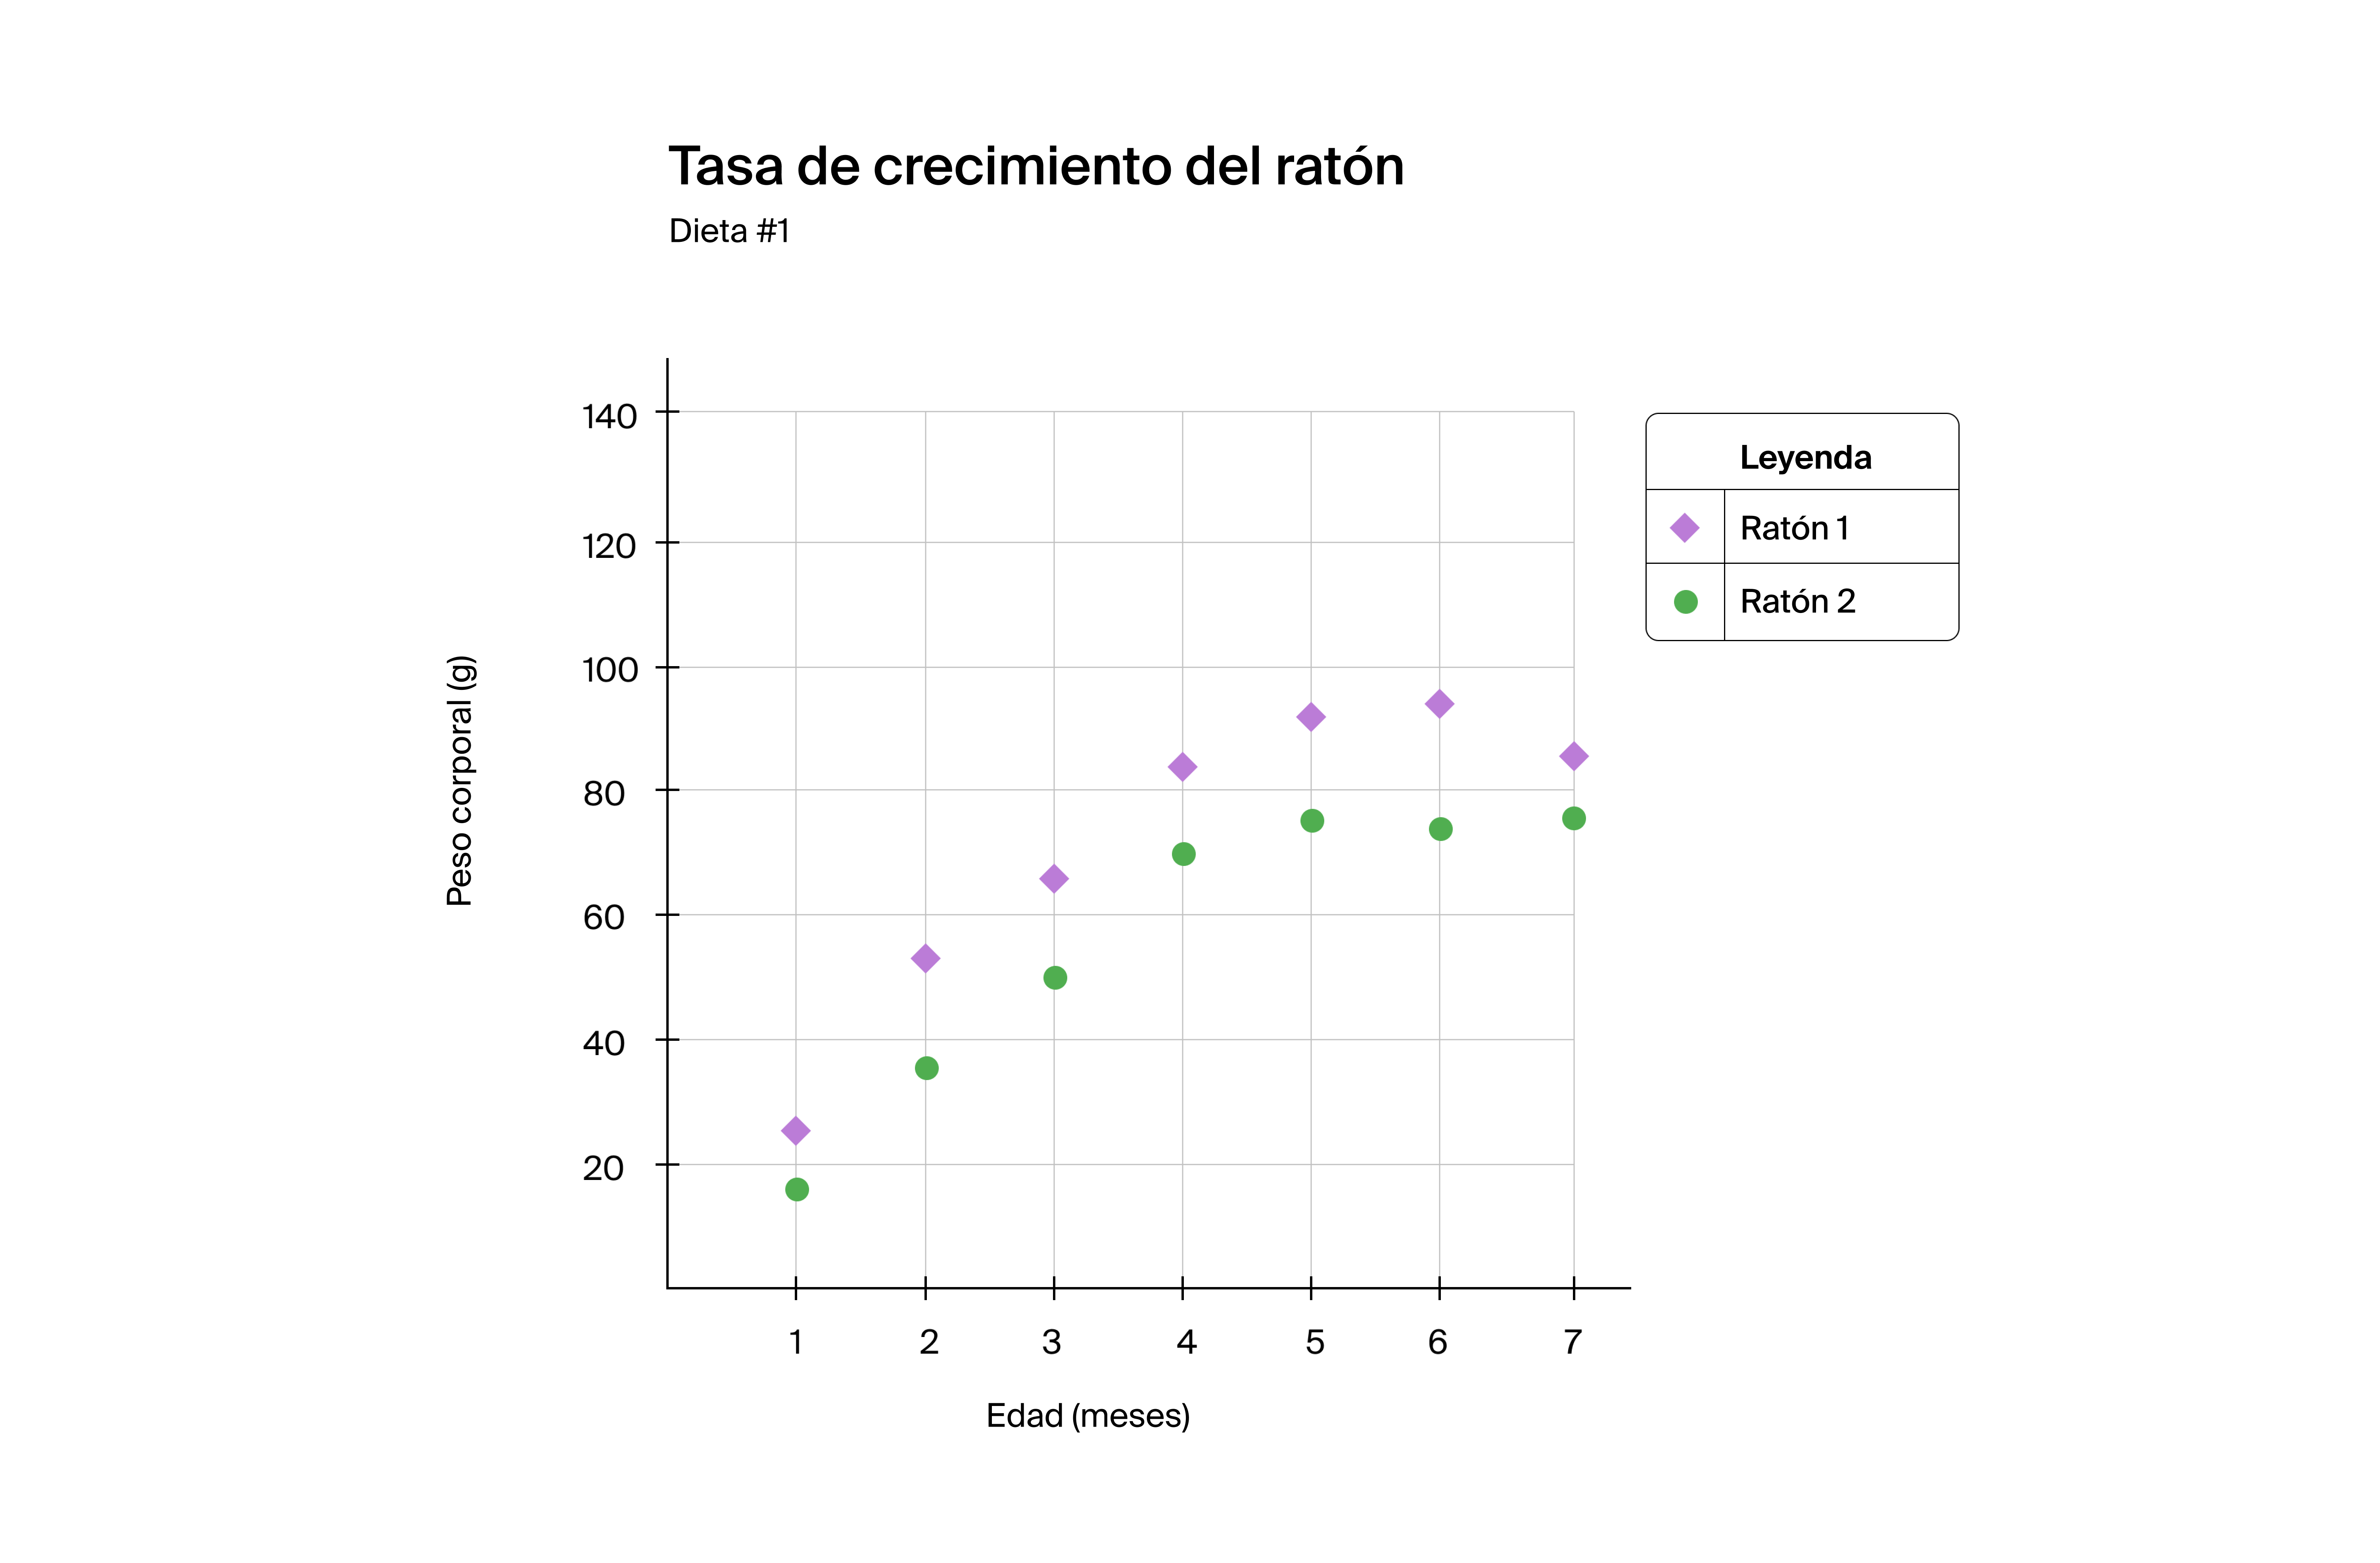

Este aspecto dramático de los gráficos tiene sus ventajas y sus desventajas. A veces, una visualización puede ser engañosa si no tomas en cuenta toda la información, tales como el rango de valores para cada eje y qué representan aquellos ejes. Cuando trabajes con gráficos, no te dejes engañar. Estudia exactamente lo que muestra cada gráfico antes de apresurarte a sacar conclusiones.

Recuerda también que, como analista, eres responsable de los gráficos que produces. Trata de predecir qué conclusiones sugieren y piensa si son razonables y honestas.

### Elementos de un buen gráfico
Las buenas gráficas ayudan a arrojar conclusiones fácilmente a partir de los datos. Nos proporcionan un buen entendimiento inicial de los datos sin necesidad de un análisis profundo. Sin embargo, la siguiente gráfica no es muy útil para este propósito, ya que no resulta claro qué representan los datos. Repasemos algunos elementos que podríamos agregar a este gráfico para mejorarlo.

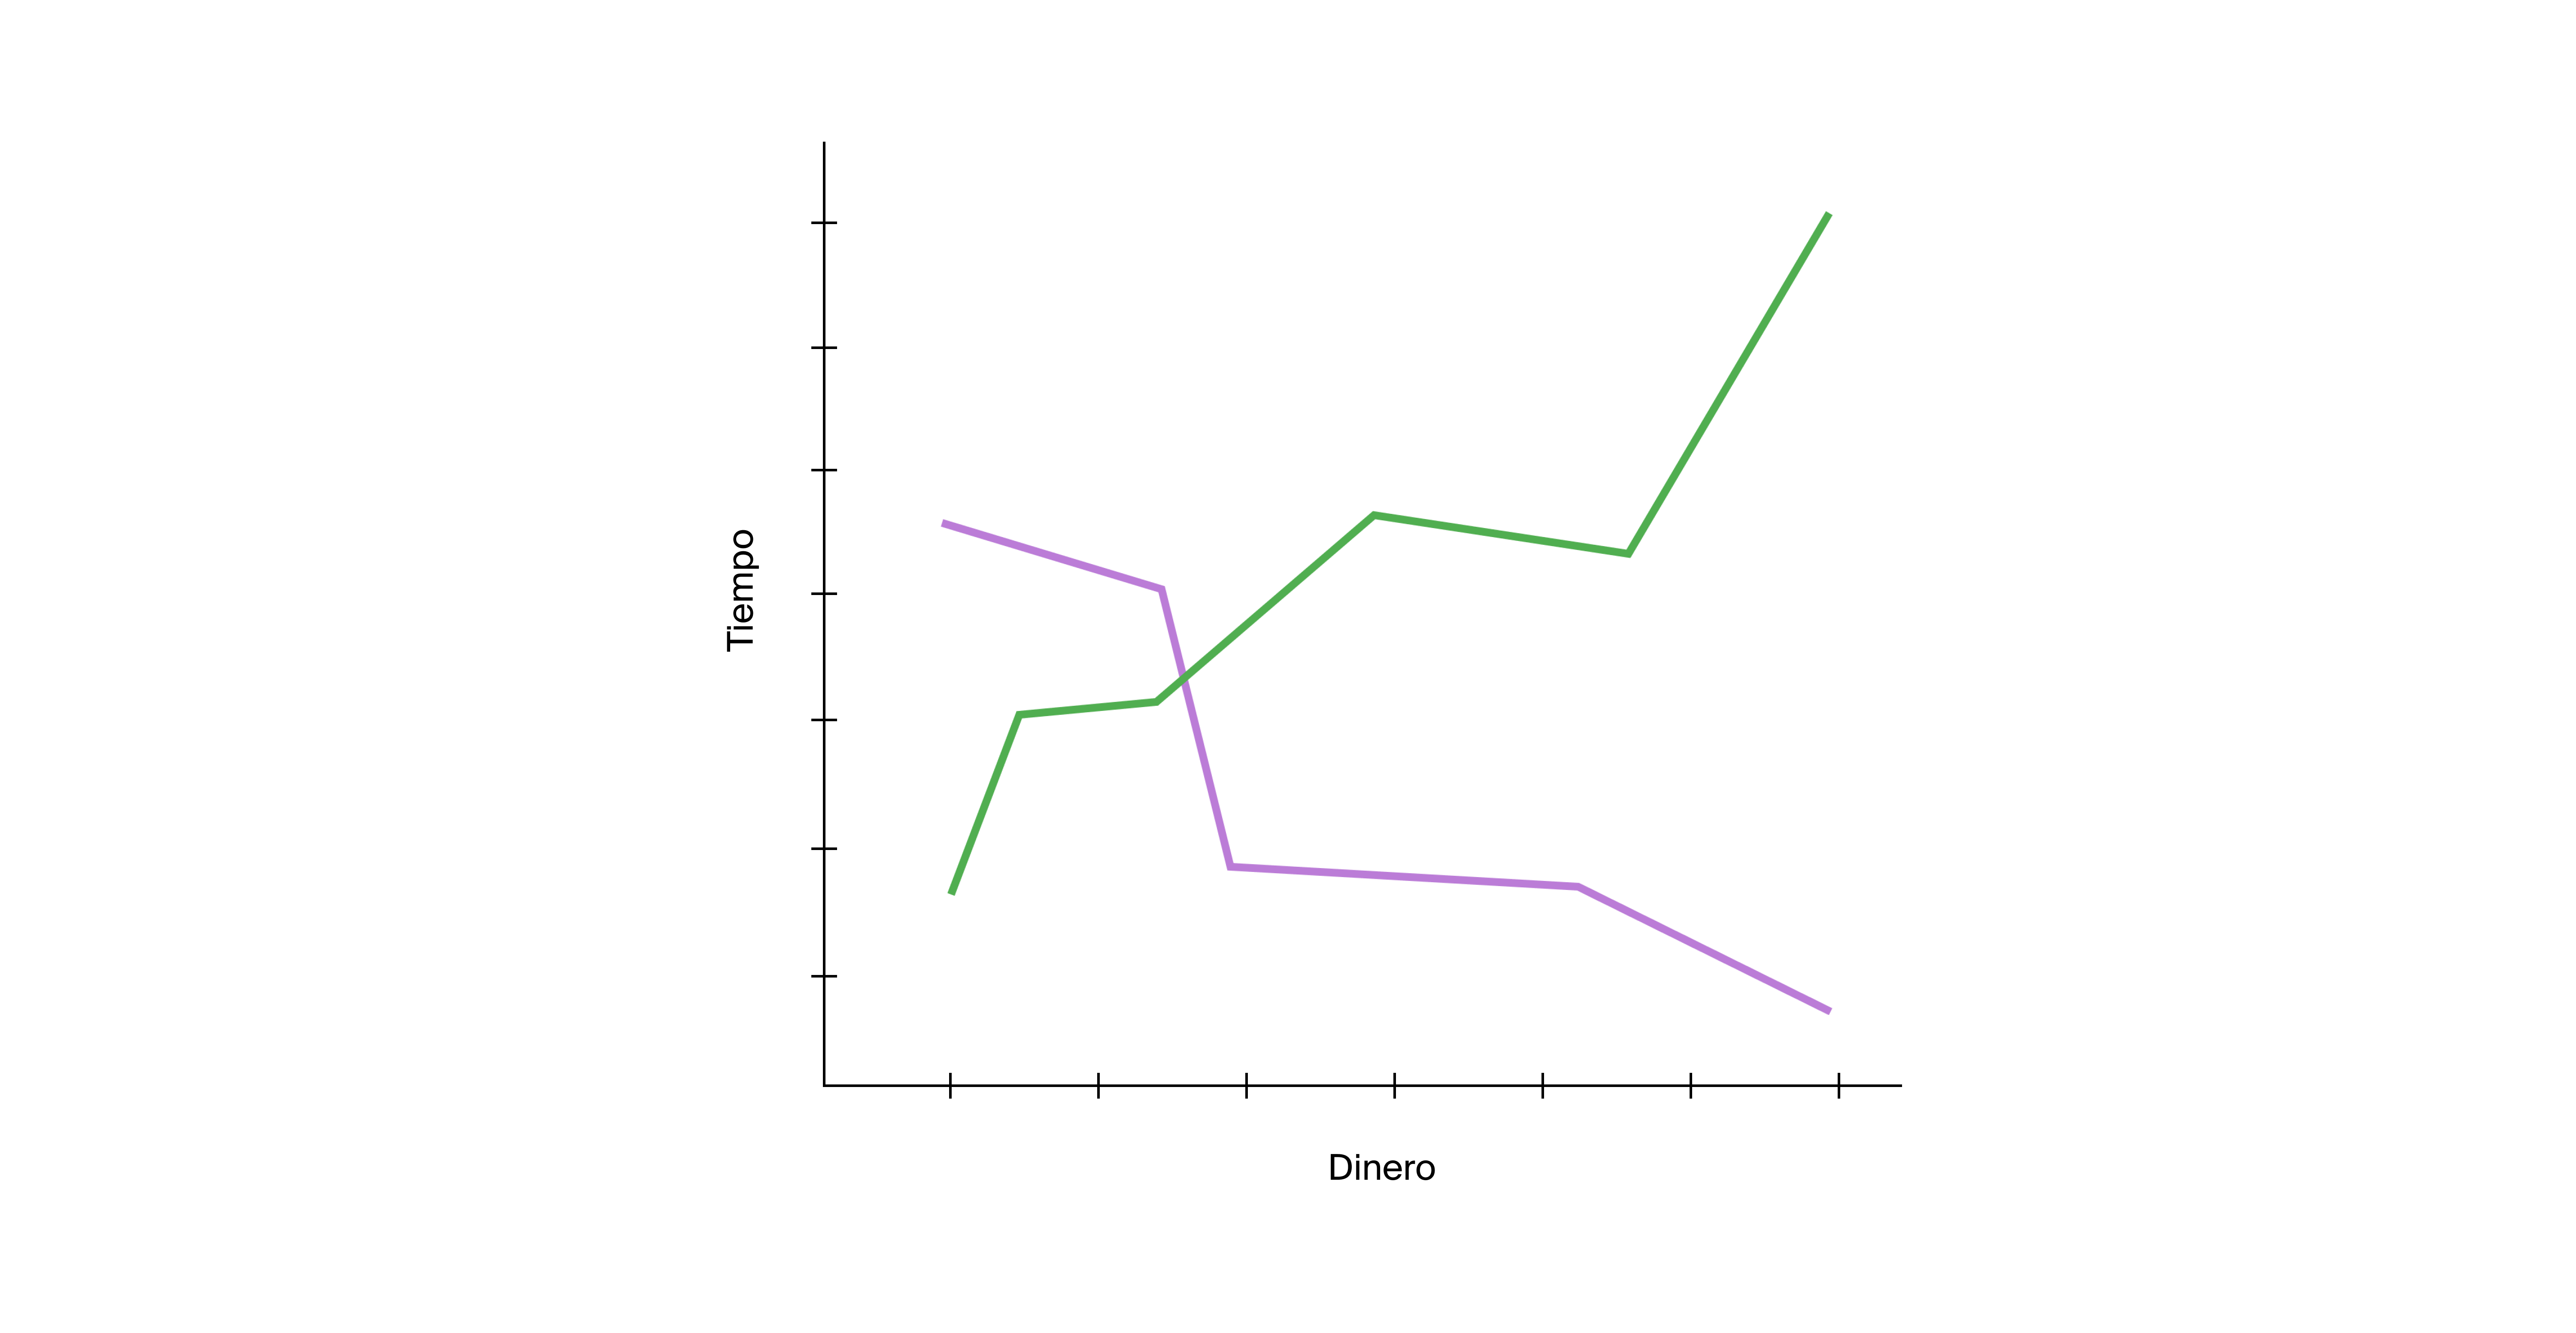

#### Títulos
Cada gráfico debe tener un título descriptivo que comunique inmediatamente a la audiencia por qué fue creado.

Los títulos no deben simplemente reiterar lo que las etiquetas de los ejes ya comunican. Mira el gráfico del peso corporal del ratón, por ejemplo. Se titula ”Tasa de crecimiento de ratones (Dieta #1)”, que es mucho mejor que un título como “Peso corporal del ratón frente a la edad”. Queda claro a partir de las etiquetas de los ejes que estamos representando el peso corporal frente a la edad, por lo que un título como ese no proporciona información adicional.

Incluso, los títulos pueden incluir un subtítulo donde se explique la conclusión del gráfico. Por ejemplo, “Tasa de crecimiento de ratones (Dieta #1): el peso de los ratones crece linealmente con la edad hasta alrededor de los 4 meses, después de lo cual su peso comienza a estabilizarse”.

#### Ejes
Los ejes siempre deben etiquetarse para evitar así cualquier ambigüedad sobre las cantidades o categorías que se grafican.

Si un eje representa alguna cantidad física (p. ej., peso, velocidad, tiempo, dinero), siempre debe incluir las unidades de dicha cantidad en la etiqueta del eje. También se deben incluir marcas de eje con etiquetas numéricas o categóricas para que la audiencia tenga una idea de la escala de los datos.

Normalmente, la mejor opción es representar la variable independiente en el eje X, mientras la variable dependiente se representa en el eje Y.

- La variable independiente es la causa de la variación en el gráfico. Su valor es independiente de otras variables en tu gráfico.
- La variable dependiente es el efecto. Su valor depende de los cambios en la variable independiente.

#### Leyendas
Las leyendas son útiles cuando trazas más de un conjunto de datos en el mismo gráfico.

El gráfico de ratones incluye una leyenda codificada por colores que le dice a la audiencia que hay datos para dos ratones diferentes, lo que básicamente nos permite trazar una tercera variable (número de ratón) en un gráfico 2D mediante el uso de colores para diferenciar los ratones. La leyenda comunica el significado de cada color (morado para el ratón 1 y verde para el ratón 2).

No todos los gráficos requieren una leyenda, aún así, una leyenda puede ayudar a reiterar la información para algunos lectores.

# Checklist para crear buenos gráficos en análisis de datos

## Títulos
- [ ] ¿El título es **descriptivo** y comunica el propósito del gráfico?
- [ ] ¿Evita repetir lo que ya dicen las etiquetas de los ejes?
- [ ] ¿Incluye un **subtítulo opcional** que resuma la conclusión principal del gráfico?

## Ejes
- [ ] ¿Ambos ejes están **etiquetados claramente**?
- [ ] ¿Se incluyen **unidades de medida** cuando corresponde (peso, tiempo, dinero, etc.)?
- [ ] ¿Las marcas de los ejes tienen etiquetas numéricas o categóricas para mostrar la escala?
- [ ] ¿La variable **independiente** está en el eje X y la **dependiente** en el eje Y?

## Leyendas
- [ ] ¿Se incluye una leyenda cuando hay más de un conjunto de datos?
- [ ] ¿La leyenda explica claramente el significado de colores, símbolos o estilos de línea?
- [ ] ¿La leyenda está ubicada en un lugar visible sin obstruir el gráfico?
- [ ] ¿Se evita incluir una leyenda innecesaria si el gráfico es suficientemente claro?

## Claridad y diseño
- [ ] ¿El gráfico evita elementos redundantes o decorativos que distraigan?
- [ ] ¿Los colores y estilos son consistentes y accesibles (ej. contraste suficiente)?
- [ ] ¿El gráfico comunica la **conclusión principal** de forma inmediata?
- [ ] ¿El diseño es limpio y fácil de interpretar para la audiencia objetivo?


#### Ejemplo de un gráfico que cumple el checklist:

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px

cases = [33, 61, 86, 112, 116, 129, 192, 174, 344, 304, 327, 246, 320, 339, 376]

dates = ['March<br>'] * len(cases)
day = 18
for i in range(len(dates)):
    dates[i] = dates[i] + str(day)
    day = day + 1
dates[-1] = 'April<br>1'

labels = dict(date="Date", cases="Number of cases")
markers = dict(size=30, line=dict(width=2, color='black'), color='white')
title = dict(text='New Cases Per Day', font=dict(color='white', size=30))
yaxis = dict(tickmode='linear', tick0=30, dtick=30)

df = pd.DataFrame({'cases': cases, 'date': dates})

fig = px.line(df, y='cases', x='date', text='cases', markers=True, labels=labels, title="New Cases Per Day")

fig.update_xaxes(showgrid=False, color='white', tickangle=0)
fig.update_yaxes(color='white', gridcolor='#5c5a5c', gridwidth=2, range=[15, 400])
fig.update_traces(marker=markers, line_color='white', line_width=6)
fig.update_layout(title=title,
                  title_x=0.5,
                  paper_bgcolor='#070230',
                  plot_bgcolor='#070230',
                  yaxis=yaxis,
                  xaxis_type='category')
fig.add_annotation(text='TOTAL CASES', 
                    align='right',
                    showarrow=False,
                    font=dict(color='white', size=8),
                    xref='paper',
                    yref='paper',
                    x=1.08,
                    y=1.25)
fig.add_annotation(text='3,342', 
                    align='right',
                    showarrow=False,
                    font=dict(color='white', size=23),
                    xref='paper',
                    yref='paper',
                    x=1.071,
                    y=1.2)

fig.show()

### Pandas plot() y plt.show()
Comencemos aprendiendo sobre el método plot() de pandas y el método show() de la biblioteca pyplot de Matplotlib. Aquí hay un ejemplo de cómo podemos llamar plot() para crear una gráfica en pandas y después usar show() para mostrar claramente una gráfica.

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.DataFrame({'a':[2, 3, 4, 5], 'b':[4, 9, 16, 25]})
print(df)

df.plot()
# df['b'].plot() # si solo queremos mostrar la columna b

plt.show() # opcional, pero es buen práctica, ya que sin él, solo en jupyter notebook se mostraría, pero en otros entornos no

# plt.savefig('myplot.png') # plt también nos permite guardar gráficos como imagen

### Personalización de gráficas con parámetros plot()
Tal vez notaste que los gráficos que hemos hecho hasta ahora son bastante básicos y no cumplen con las buenas prácticas que aprendiste anteriormente en este capítulo. Bueno, plot() tiene muchos parámetros adicionales que podemos usar para arreglar esto.

Títulos
Los títulos de los gráficos se pasan al parámetro title= como strings

#### Estilos de línea
Nuestra gráfica no es tan mala, pero un gráfico de líneas podría no ser lo mejor aquí, ya que implica que tenemos puntos de datos a lo largo de toda la línea cuando, de hecho, sólo tenemos cuatro. Para que le resulte obvio a cualquiera que mire el gráfico, sería mejor usar un estilo de marcado distinto para los puntos de datos.

Para cambiar el estilo de marcador del gráfico, puedes usar el parámetro style=. Vamos a pasarle un argumento de 'o' para que cada valor se marque como un punto.

[Click aquí para info sobre más estilos](https://matplotlib.org/stable/api/markers_api.html)

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.DataFrame({'a':[2, 3, 4, 5], 'b':[4, 9, 16, 25]})

df.plot(title='A y B', style="x") # default "-", "o", "o-", "x"
plt.show()

### Ejes
En todos los gráficos que has visto hasta ahora, el eje horizontal contiene los valores del índice DataFrame. Pero, ¿qué sucede si deseas trazar dos columnas una frente a la otra? Podemos usar los parámetros x= y y= para lograr esto:

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.DataFrame({'a':[2, 3, 4, 5], 'b':[4, 9, 16, 25]})

df.plot(x='b', y='a', title='A vs B', style='o-')
plt.show()

### Ejercicio 1 plots
Tu tarea es crear un gráfico con forma de estrellas rosas utilizando los datos en df. Para tu comodidad, todos los atributos necesarios se enumeran a continuación. Sigue las instrucciones para lograr el resultado deseado. Si lo necesitas, consulta la sección de repaso para recordar los nombres de los parámetros.

Usando el método plot() de pandas, crea un trazo de columna 'a' frente a la columna 'c' del df que tenga los siguientes argumentos:

- El título "A vs C" (el uso de mayúsculas y minúsculas es importante, así que puedes copiarlo y pegarlo).
- Un estilo de marcador de estrella (puedes usar un asterisco '*' para lograrlo).
- Marcadores de color rosa fuerte (utiliza el nuevo y obvio parámetro color= para hacerlo, con el argumento 'hotpink')
- Tamaño de la gráfica de 5 por 5 pulgadas.
- Rango del eje X de 0 a 12.
- Rango del eje Y de 1 a 6.
- Eje X con la leyenda "C".
- Eje Y con la leyenda "A".

In [ ]:
# Solución:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.DataFrame({'a':[2, 3, 4, 5], 'b':[4, 9, 16, 25], 'c':[1, 3, 6, 10]})

df.plot(
    x="c",
    y="a",
    xlabel="C",
    ylabel="A",
    xlim=[0, 12],
    ylim=[1, 6],
    style="*-",
    title="A vs C",
    color="hotpink",
    figsize=[5, 5],
    legend="My graphic", #optional
    grid=True #optional
)

plt.show()

### Ejercicio 2 plots
Para hacer el análisis más interesante y fácil de entender, usaremos el mismo conjunto de datos de antes, pero esta vez analizaremos height frente a age en lugar de weight. Vas a crear un gráfico de dispersión que muestre la relación entre estas dos variables.

Los datos de altura y peso del adulto se han leído en la variable df para ti en el precódigo. Utiliza el argumento kind='scatter' para crear el gráfico de dispersión deseado. Da al gráfico los siguientes argumentos:

El título “Adult heights” ("Altura de adultos" en Espanol) (el uso de mayúsculas y minúsculas es importante).
Valor alfa de 0.36.
Tamaño de la gráfica de 8 por 6 pulgadas.
Eje X etiquetado “Age / years” (“Edad / anos“ en Espanol).
Eje Y etiquetado “Height / inches” ("Altura / pulgadas" en Espanol).

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv('./datasets/height_weight.csv')

df.plot( # .sort_values()
    title='Adult heights',
    x='age',
    y='height',
    kind='scatter',
    alpha=0.36,
    figsize=[8, 6],
    xlabel='Age / years',
    ylabel='Height / inches'
)


plt.show()

## Coeficiente de correlación
Una cosa es mirar el gráfico, pero también necesitamos una forma numérica para describir la correlación.

Para cuantificar cómo una variable tiende a cambiar cuando la otra variable cambia, utilizamos el coeficiente de correlación de Pearson, conocida comúnmente como el coeficiente de correlación. Este coeficiente puede tomar cualquier valor entre -1 y 1.

Un valor de -1 representa una correlación lineal negativa perfecta, mientras que un valor de 1 representa una correlación lineal positiva perfecta. En general, el coeficiente de correlación funciona de este modo:

Si uno de los valores incrementa junto con el otro, el coeficiente de correlación es positivo.
Si uno permanece igual mientras el otro cambia, el coeficiente es 0.
Si uno se reduce mientras el otro incrementa, el coeficiente es negativo.
Cuanto más cerca esté el coeficiente de -1 o 1, más fuerte será la correlación. Por otro lado, un valor de 0 puede significar que no hay correlación o que hay una conexión no lineal compleja que el coeficiente no puede reflejar.

Para ayudarte a entender la relación entre el coeficiente de correlación y la distribución de puntos en un gráfico de dispersión, hemos incluido una gráfica interactiva. Puedes cambiar el coeficiente de relación y observar cómo cambia la dispersión de los puntos de datos.

Observa que hay diferentes gráficos de dispersión que podrían dar como resultado el mismo coeficiente de correlación; este solo 
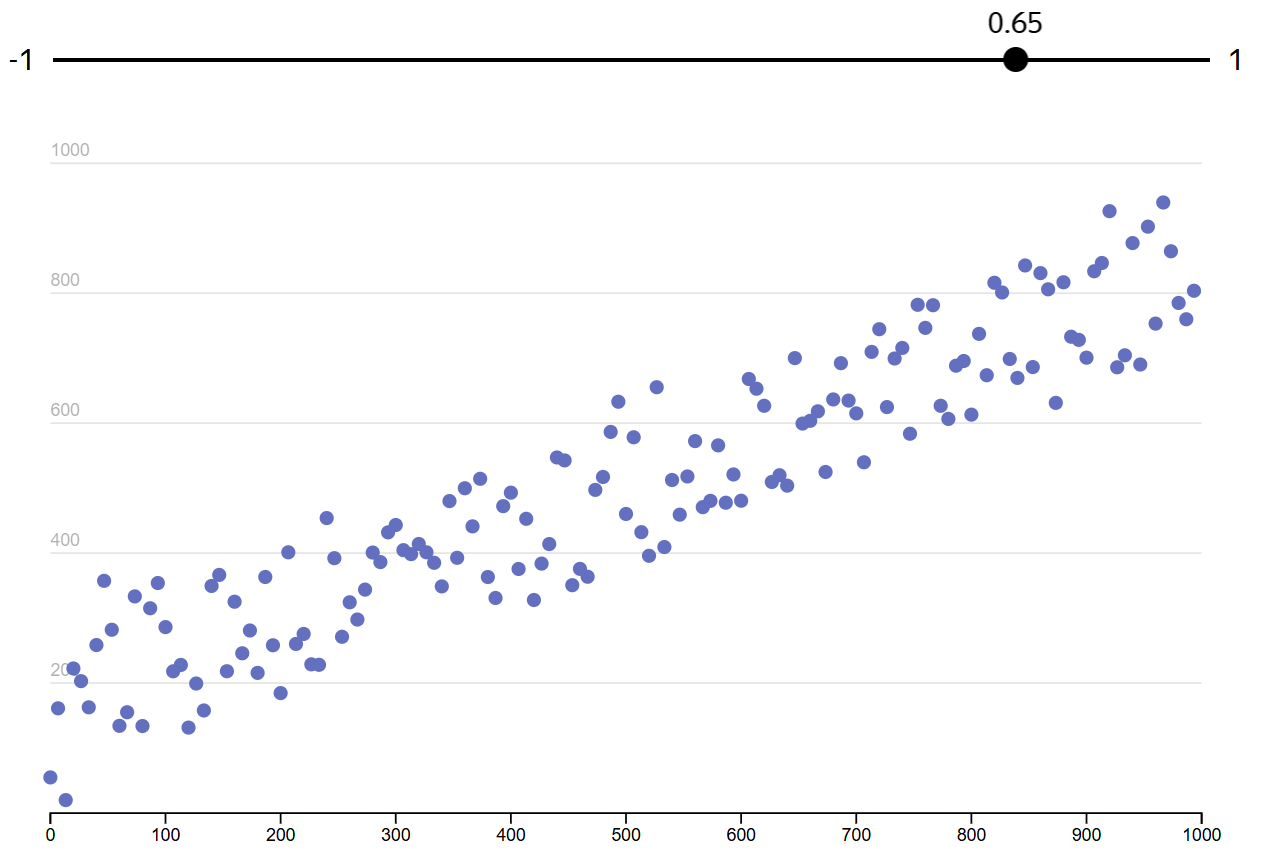

### Calcular el coeficiente de correlación
En pandas, puedes calcular el coeficiente de correlación de Pearson usando el método corr(). Para hacerlo, aplícalo a la columna con la primera variable, y pasa la columna con la segunda variable como un parámetro. No importa el orden de las variables. Por ejemplo:es un ejemplo.

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv('./datasets/height_weight.csv')

print(df['height'].corr(df['weight']))
print("-----------------------------------------")
print(df.corr())

### Crear matrices de dispersión
En la lección anterior, encontramos una fuerte correlación entre la altura y el peso, pero en la vida real, las cosas rara vez son tan simples. Si nos interesa explorar los factores que contribuyen al peso de las personas, hay mucho más que considerar además de la altura. Por ejemplo, también podríamos querer saber cómo la edad y el sexo se correlacionan con el peso, o cómo se correlacionan entre sí.

Desafortunadamente, es imposible trazar los cuatro parámetros en el mismo gráfico de forma coherente. Sin embargo, podemos crear gráficos de dispersión para cada posible par de parámetros: altura y peso, altura y edad, peso y sexo, etcétera. Este conjunto de gráficos por pares se denomina matriz de dispersión.

En pandas, podemos construir matrices de dispersión usando la función plotting.scatter_matrix(): 

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv('./datasets/height_weight.csv')

pd.plotting.scatter_matrix(df, figsize=(9, 9))
plt.show()

### Gráficos de líneas
Los gráficos de líneas son excelentes cuando tienes datos que se conectan cronológicamente y cada punto de tiempo de los datos tiene alguna dependencia con el punto anterior. Cosas como datos de temperatura, datos de tráfico y datos del mercado de valores son buenos candidatos para los gráficos de líneas.

En esta lección, vamos a trabajar con datos del mercado de valores de Starbucks (SBUX) desde 2015 hasta 2019. Obtuvimos este conjunto de datos de Yahoo Finanzas y lo modificamos para que contuviera solo un subconjuto de las columnas disponibles.

Vamos a echar un vistazo a los datos:

In [ ]:
import pandas as pd

df = pd.read_csv('./datasets/sbux.csv')

print(df.head())
print()
df.info()
print("------------------------------------")
df.plot(x='Date',
        y='Open',
        legend=False,
        title='Starbucks market open',
        xlabel='Date',
        ylabel='Share price / USD',
        rot=45)
plt.show()

### Ejercicio

Crea un gráfico de líneas que incluya tanto el precio de apertura como el de cierre. Para hacer esto, puedes pasar la lista de nombres de columna, cols, proporcionada en el precódigo como tu argumento para y=. Dado que tendrás dos variables diferentes en el mismo gráfico, asegúrate de incluir una leyenda esta vez. Haz que tu gráfico también cumpla con lo siguiente
- Titula Historic SBUX price ("Precio histórico de SBUX") (la distinción entre mayúsculas y minúsculas es importante- )- Eje X con la leyeda “date”
- Eje Y con la leynda “Share price  USD” ("Precio de la acción / USD"). Deja un espacio antes y después de la /, por claridad y para evitar erros- 
Leyendas de marca del eje X rotadas 50 grados.
No olvides incluir plt.show().

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv('./datasets/sbux.csv')
cols = ['Open', 'Close']

df.plot(
    title='Historic SBUX price',
    x='Date',
    y=cols,
    xlabel='Date',
    ylabel='Share price / USD',
    rot=50,
)

plt.show()

### Graficos con variables categóricas
Hasta ahora hemos estado aprendiendo cómo visualizar relaciones entre variables numéricas en nuestros datos, pero ¿qué pasa con las variables categóricas? La mayoría de los conjuntos de datos con los que trabajarás tienen una combinación de datos numéricos y categóricos.

Los gráficos de barras son una gran herramienta para comparar categorías definidas por un valor numérico.

Así que, en esta lección, haremos gráficos de barras para visualizar datos tomados de la Oficina del Censo de los Estados Unidos sobre niveles históricos de población en California, Oregón y Washington. Los gráficos de barras son una excelente opción aquí porque nos permitirán comparar propiedades numéricas (población) entre categorías (estados).

Comencemos mostrando información general sobre el conjunto de datos:

In [ ]:
import pandas as pd

df = pd.read_csv('./datasets/west_coast_pop.csv')
print(df)
print("-------------------------------------------")
df.plot(x='year', kind='bar')
plt.show()

Tal como se esperaba: un conjunto de tres barras, una para cada estado, para cada año en el conjunto de datos.

Si no especificas ninguna columna para el parámetro y=, pandas creará automáticamente una barra para cada columna en el DataFrame que no esté en el eje X; en este caso, una barra para cada población del estado.

El gráfico de barras facilita sacar ciertas conclusiones sobre los datos. Por ejemplo, podemos ver que la población de California es consistentemente mucho mayor que la de otros estados. También vemos que la población ha crecido constantemente en todos los estados.

Sin embargo, si queremos presentar estos datos a otras personas, necesitamos que se vean más profesionales:

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv('./datasets/west_coast_pop.csv')

df.plot(x='year',
        kind='bar',
        title='West coast USA population growth',
        xlabel='Year',
        ylabel='Population (millions)')

plt.legend(['CA', 'OR', 'WA'])
plt.show()

### Trazar histogramas de DataFrames

En pandas, hay dos formas de trazar histogramas:

El método hist().
El método plot() con el argumento kind='hist'.
Examinemos hist() primero:



In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv('./datasets/height_weight.csv')
df.hist()

plt.show()

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv('./datasets/height_weight.csv')

df.plot(kind='hist')

plt.show()

### Trazado de histogramas de columnas
A menudo, querrás explorar una variable a la vez. Podemos trazar un histograma para una sola columna usando hist() pasando el nombre de la columna como un argumento para el parámetro column=. Echemos un vistazo más de cerca a la columna 'height' (altura):

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv('./datasets/height_weight.csv')

df.hist(column='height')

plt.show()

De manera alternativa, podríamos trazar el mismo histograma llamando hist() sólo en la columna 'height'. Por defecto, hist() utiliza 10 contenedores. Sin embargo, para estos datos, 10 contenedores parecen demasiado bajos para captar el nivel de detalle que deseamos. Para resolverlo, podemos usar el parámetro bins= para ajustar el número de contenedores usados.

El histograma es el mismo, pero el formato predeterminado de las gráficas difiere entre métodos. Si deseas ver un histograma para una sola variable, te recomendamos usar plot() porque hist() no es compatible con todas las palabras clave de formato que has aprendido, como title=, xlabel=, ylabel=.

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv('./datasets/height_weight.csv')

df = df[df['sex']==1]
# df['height'].hist()
df.hist(column='height', bins=30)

plt.show()

### Comparación de histogramas para subconjuntos de datos
La altura del histograma trazado arriba muestra dos picos de valores más frecuentes. Esto podría deberse a las diferencias en la distribución de la estatura de hombres y mujeres. Para investigar esta cuestión, podemos trazar los histogramas de altura para hombres y mujeres por separado en la misma gráfica.

Todo lo que tenemos que hacer es filtrar el DataFrame por sexo, y luego llamar a plot() en la columna 'height'. Si hacemos esto dos veces (una para cada sexo), pandas automáticamente trazará ambos en el mismo gráfico, con el segundo histograma delante del primero:

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv('./datasets/height_weight.csv')

# esto mostrará el gráfico de hombres
df[df['sex'] == 1]['height'].plot(kind='hist', bins=20)

# esto mostrará el gráfico de mujeres
# e incluye un valor alpha para que podamos ver ambos histogramas por completo
df[df['sex'] == 2]['height'].plot(kind='hist', bins=20, alpha=0.8)

plt.legend(['Male', 'Female']) # leyenda, que sigue el mismo orden trazado anteriormente
plt.show()

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv('./datasets/height_weight.csv')

df = df.sort_values('sex').reset_index(drop=True)

df = df[df.index < 5000]

df.hist(column='height', bins=50)

plt.show()

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv('./datasets/height_weight.csv')

# separa df en dataframes separados según la edad
df_20s = df[df['age'] < 30]
df_30s = df[(df['age'] >= 30) & (df['age']  < 40)]
df_40s = df[df['age'] >= 40]

print(df_20s.shape[0])
print(df_20s['age'].min())

## Proyecto Sprint 4
### DATASETS
- 
instacart_orders.cs- v
products.c- sv
order_products.- csv
aisles- .csv
departmen
  ts.csv
## Descripción del proyecto

Para este proyecto, trabajarás con datos de Instacart.

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash. Este conjunto de datos particular fue [lanzado públicamente](https://tech.instacart.com/3-million-instacart-orders-open-sourced-d40d29ead6f2) *(materiales en inglés)* por Instacart en 2017 para una [competición Kaggle](https://www.kaggle.com/c/instacart-market-basket-analysis/overview) *(materiales en inglés)*. Los datos reales pueden descargarse directamente de la página de la competición Kaggle.

El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Tu misión es limpiar los datos y preparar un informe que brinde información sobre los hábitos de compra de los clientes de Instacart. Después de responder a cada pregunta, escribe una breve explicación de tus resultados en una celda markdown de tu Jupyter notebook.

Este proyecto requerirá que hagas gráficos que comuniquen tus resultados. Asegúrate de que cualquier gráfico que vayas a crear tenga un título, ejes etiquetados y una leyenda si es necesario; e incluye `plt.show()` al final de cada celda con un gráfico.

Si deseas más consejos sobre el proyecto, puedes mirar este video:  
[Data Wrangling (YouTube)](https://www.youtbe.com/embed/2D01DWihCTo)

---

## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos:

- **instacart_orders.csv**: cada fila corresponde a un pedido en la aplicación Instacart.
  - `order_id`: número de ID único de cada pedido.
  - `user_id`: número de ID único de cada cliente.
  - `order_number`: número de veces que este cliente ha hecho un pedido.
  - `order_dow`: día de la semana en que se hizo un pedido (0 = domingo).
  - `order_hour_of_day`: hora del día en que se hizo el pedido.
  - `days_since_prior_order`: días transcurridos desde el pedido anterior.

- **products.csv**: cada fila corresponde a un producto único.
  - `product_id`: ID único de cada producto.
  - `product_name`: nombre del producto.
  - `aisle_id`: ID único de la categoría de pasillo.
  - `department_id`: ID único del departamento.

- **order_products.csv**: cada fila corresponde a un artículo pedido en un pedido.
  - `order_id`: ID único de cada pedido.
  - `product_id`: ID único de cada producto.
  - `add_to_cart_order`: orden secuencial en que se añadió al carrito.
  - `reordered`: 0 si nunca se pidió antes, 1 si ya se había pedido.

- **aisles.csv**
  - `aisle_id`: ID único de cada pasillo.
  - `aisle`: nombre del pasillo.

- **departments.csv**
  - `department_id`: ID único de cada departamento.
  - `department`: nombre del departamento.

---

## Instrucciones para completar el proyecto

### Paso 1
Abre los archivos de datos (`instacart_orders.csv`, `products.csv`, `aisles.csv`, `departments.csv`, `order_products.csv`) y revisa su contenido.  
Ten en cuenta que los archivos tienen un formato no estándar, por lo que deberás ajustar los argumentos de `pd.read_csv()`.  
Recuerda que `order_products.csv` contiene muchas filas, así que usa `info(show_counts=True)` si quieres ver los recuentos no nulos.

### Paso 2
Preprocesa los datos:
- Verifica y corrige tipos de datos (IDs como enteros).
- Identifica y completa valores ausentes.
- Identifica y elimina duplicados.

Explica qué valores ausentes y duplicados encontraste, cómo los trataste y por qué.

### Paso 3
Una vez procesados los datos, realiza el siguiente análisis:

#### [A] (obligatorio)
1. Verifica que `order_hour_of_day` esté entre 0–23 y `order_dow` entre 0–6.  
2. Gráfico: número de personas que hacen pedidos según la hora del día.  
3. Gráfico: pedidos por día de la semana.  
4. Gráfico: tiempo de espera hasta el próximo pedido, comenta valores mínimos y máximos.  

#### [B] (obligatorio)
1. Compara distribuciones de `order_hour_of_day` en miércoles y sábados con histogramas.  
2. Distribución del número de pedidos por cliente.  
3. Top 20 productos más pedidos (ID y nombre).  

#### [C] (obligatorio)
1. Distribución del número de artículos por pedido.  
2. Top 20 artículos más reordenados (ID y nombre).  
3. Tabla: proporción de reordenamiento por producto.  
4. Proporción de productos reordenados por cld
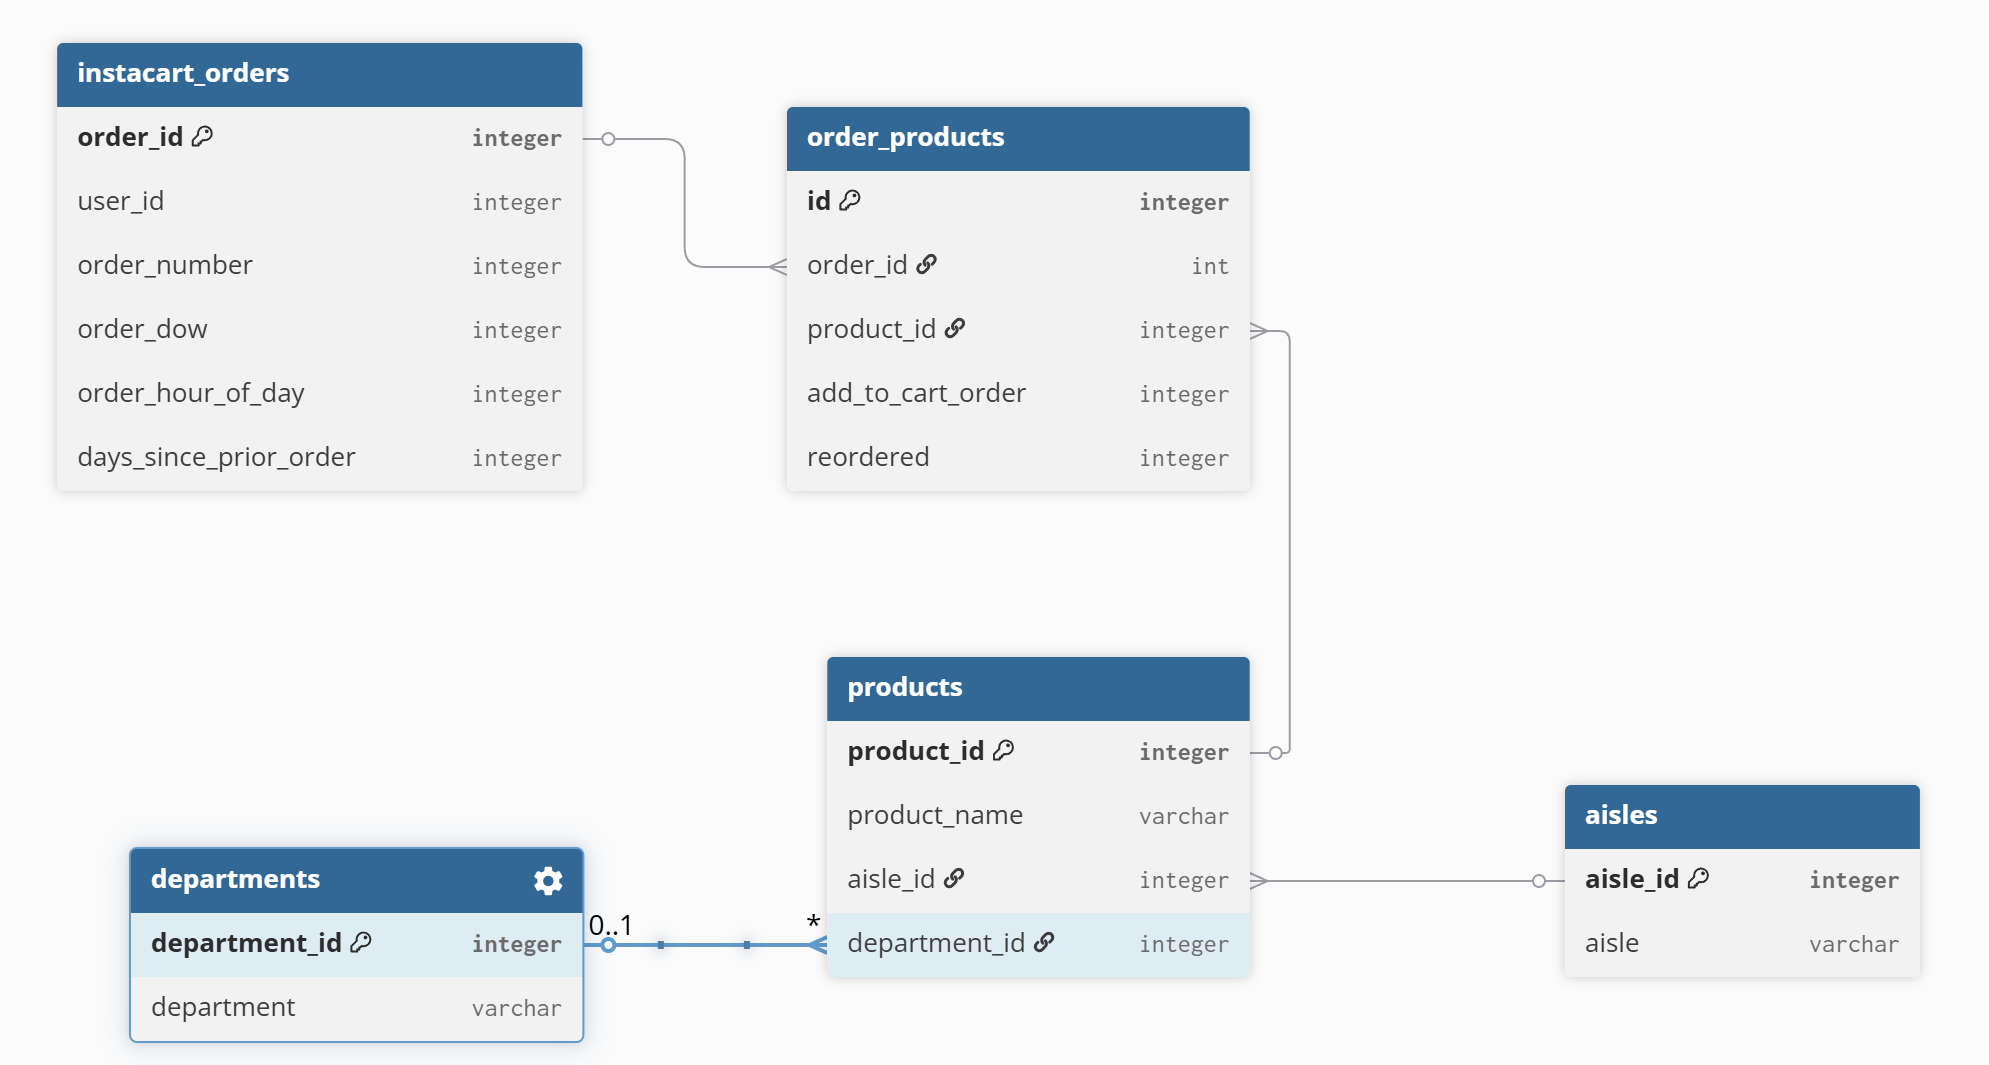er="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

este video:

In [ ]:
import pandas as pd

df_departments = pd.read_csv("./datasets/sprint4/aisles.csv", sep=";")
df_products = pd.read_csv("./datasets/sprint4/products.csv", sep=";")
df_departments = pd.read_csv("./datasets/sprint4/departments.csv", sep=";")
df_order_products = pd.read_csv("./datasets/sprint4/order_products.csv", sep=";")
df_instacart_orders = pd.read_csv("./datasets/sprint4/instacart_orders.csv", sep=";")

df_instacart_orders.info()